### Transformer ➔ GPT-1 핵심 변경점
---
1. 인코더 라인 제거

2. 디코더 라인에서 Encoder-Decoder Cross Attention 레이어 제거

3. 입출력 포맷의 단일 통합
    - 질문과 정답 문장을 Separator ([SEP]) 특수 토큰을 사이에 두고 하나의 긴 단일 시퀀스(Single Sequence)로 묶어서 모델에 한 번에 주입하는 형태로 변경
    - 입력 예시: 오늘 너무 힘들다 [SEP] 고생 많았어요 . [EOS]



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import sentencepiece as spm

import os
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'data', 'ex08')
data_path = os.path.join(base_path, 'ChatbotData.csv')

In [4]:
# utils
def analyze_sequence_length(csv_path, tokenizer, sep_token="[SEP]"):
    """
    Chatbot 데이터의 Q + [SEP] + A 결합 문장에 대한 토큰 길이 분포를 분석하고 시각화합니다.
    """
    # 1. 데이터 로드
    df = pd.read_csv(csv_path)
    
    token_counts = []
    eos_len = 1 # 끝에 붙는 [EOS] 토큰 1개 반영
    
    print("🔄 데이터 토큰화 진행 중...")
    for _, row in df.iterrows():
        q_text = str(row['Q'])
        a_text = str(row['A'])
        
        # GPT-1 포맷식 결합 방식 모사
        combined_text = f"{q_text} {sep_token} {a_text}"
        
        # 토크나이저를 통해 실제 서브워드 토큰 ID 리스트로 변환
        tokens = tokenizer.encode(combined_text)
        
        # 실제 입력에 들어갈 총 길이 수집 ([EOS] 포함)
        token_counts.append(len(tokens) + eos_len)
        
    token_counts = np.array(token_counts)
    
    # 2. 통계치 계산
    min_len = np.min(token_counts)
    max_len = np.max(token_counts)
    mean_len = np.mean(token_counts)
    median_len = np.median(token_counts)
    
    # 95%와 99%의 데이터가 커버되는 임계 길이 확인 (max_len 선정의 핵심 지표)
    p95 = np.percentile(token_counts, 95)
    p99 = np.percentile(token_counts, 99)
    
    print("\n================ 📈 토큰 길이 통계 결과 ================")
    print(f"• 최소 토큰 길이: {min_len}")
    print(f"• 최대 토큰 길이: {max_len}")
    print(f"• 평균 토큰 길이: {mean_len:.2f}")
    print(f"• 중앙 토큰 길이: {median_len}")
    print(f"• 전체 데이터의 95%가 포함되는 길이: {int(p95)}")
    print(f"• 전체 데이터의 99%가 포함되는 길이: {int(p99)}")
    print("========================================================")
    
    # 3. 히스토그램 시각화
    plt.figure(figsize=(10, 6))
    
    # 히스토그램 그리기
    n, bins, patches = plt.hist(token_counts, bins=30, color='teal', edgecolor='black', alpha=0.7)
    
    # 주요 지표 수직선 표시
    plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean ({mean_len:.1f})')
    plt.axvline(p95, color='orange', linestyle='--', linewidth=2, label=f'95th Pct ({int(p95)})')
    plt.axvline(p99, color='purple', linestyle=':', linewidth=2, label=f'99th Pct ({int(p99)})')
    
    plt.title("Q + [SEP] + A Sequence Token Length Distribution", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Token Length (Count)", fontsize=12, labelpad=10)
    plt.ylabel("Number of Samples", fontsize=12, labelpad=10)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # 분석 결과 추천 모델 max_len 반환
    return int(p99)


In [24]:
# tokenizer 
class SentencePieceTokenizer:
    def __init__(self, model_prefix='spm_chatbot', vocab_size=8000, 
                 pad='[PAD]', unk='[UNK]', bos='[BOS]', eos='[EOS]', sep='[SEP]'):
        self.model_prefix = model_prefix
        self.vocab_size = vocab_size
        self.model_path = f"{model_prefix}.model"
        self.sp = spm.SentencePieceProcessor()
        
        # 특수 토큰 문자열 저장
        self.special_tokens = {
            'pad': pad, 'unk': unk, 'bos': bos, 'eos': eos, 'sep': sep
        }
        
        # 💡 [개선] 이미 학습된 모델 파일이 있다면 인스턴스 생성 시 자동 로드
        if os.path.exists(self.model_path):
            self.load_tokenizer()
        else:
            print(f"⚠️ 모델 파일({self.model_path})이 아직 존재하지 않습니다. 최초 1회 'train_tokenizer()'를 실행해 주세요.")
        
    def train_tokenizer(self, corpus_path):
        """텍스트 코퍼스 파일을 기반으로 SentencePiece 모델을 학습합니다."""
        print("Creating and training SentencePiece tokenizer...")
        
        spm.SentencePieceTrainer.train(
            input=corpus_path,
            model_prefix=self.model_prefix,
            vocab_size=self.vocab_size,
            character_coverage=1.0,
            model_type='bpe',  # Byte Pair Encoding 방식 적용
            max_sentence_length=999999,
            pad_id=0, unk_id=1, bos_id=2, eos_id=3,
            pad_piece=self.special_tokens['pad'], 
            unk_piece=self.special_tokens['unk'],
            bos_piece=self.special_tokens['bos'], 
            eos_piece=self.special_tokens['eos'],
            # 💡 [개선] GPT-1 전처리에 필요한 [SEP] 토큰이 파편화되지 않도록 특수 심볼로 강제 등록
            user_defined_symbols=[self.special_tokens['sep']] 
        )
        self.load_tokenizer()
        
    def load_tokenizer(self):
        """학습된 모델 파일을 프로세서에 로드합니다."""
        if os.path.exists(self.model_path):
            self.sp.load(self.model_path)
            print(f"Successfully loaded SentencePiece model from {self.model_path}")
        else:
            raise FileNotFoundError(f"Model file not found at {self.model_path}. Train the tokenizer first.")
            
    def encode(self, text, add_bos=False, add_eos=False):
        """문장을 인덱스 리스트로 변환합니다."""
        tokens = self.sp.encode_as_ids(text)
        if add_bos:
            # 📌 [싱크 교정]: 내부 호출도 함수 구조에 맞게 변경
            tokens = [self.bos_id()] + tokens
        if add_eos:
            tokens = tokens + [self.eos_id()]
        return tokens
        
    def decode(self, ids):
        """인덱스 리스트를 다시 문장으로 복원합니다."""
        # 💡 [개선] 하드코딩 제거: 토크나이저 엔진에 등록된 ID를 동적으로 추적하여 필터링
        # 📌 [싱크 교정]: 프로퍼티가 아닌 함수를 호출하도록 괄호() 추가
        ignore_ids = [self.pad_id(), self.bos_id(), self.eos_id()]
        clean_ids = [int(i) for i in ids if i not in ignore_ids]
        return self.sp.decode_ids(clean_ids)

    def get_vocab_size(self):
        # 훈련 시 지정한 크기와 실제 빌드된 사전 크기 매칭 보장
        return self.sp.get_piece_size() if os.path.exists(self.model_path) else self.vocab_size
        
    # =========================================================================
    # 🎯 [프레임워크 스타일 싱크]: @property를 걷어내고 정석적인 '메서드(함수)' 형태로 변경
    # =========================================================================
    def pad_id(self):
        # 모델 파일이 로드된 상태면 순정 라이브러리 함수를 호출하고, 학습 전이면 기본 인덱스 0 리턴
        return self.sp.pad_id() if os.path.exists(self.model_path) else 0

    def eos_id(self):
        return self.sp.eos_id() if os.path.exists(self.model_path) else 3

    def bos_id(self):
        return self.sp.bos_id() if os.path.exists(self.model_path) else 2

    def unk_id(self):
        return self.sp.unk_id() if os.path.exists(self.model_path) else 1

    def sep_id(self):
        # [SEP] 토큰은 사용자 정의 기볼이므로 piece_to_id를 통해 내부 인덱스를 동적으로 찾아옵니다.
        if os.path.exists(self.model_path):
            _id = self.sp.piece_to_id(self.special_tokens['sep'])
            # 만약 못 찾아서 UNK_ID가 반환된다면 관례상 지정했던 4번을 안전하게 디폴트 리턴
            return _id if _id != self.sp.unk_id() else 4
        return 4


class GPT1PretrainDataset(Dataset):
    def __init__(self, csv_path, tokenizer, max_len=26): # MAX_LEN 싱크 맞춤
        self.tokenizer = tokenizer
        self.max_len = max_len
        
        self.pad_id = tokenizer.pad_id() if hasattr(tokenizer, 'pad_id') else 0
        self.eos_id = tokenizer.eos_id() if hasattr(tokenizer, 'eos_id') else 3
        self.sep_token = "[SEP]" 
        
        self.df = pd.read_csv(csv_path)
        print(f"📋 총 {len(self.df)}개의 대화 쌍을 GPT-1 포맷으로 전처리합니다.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        q_text = str(row['Q'])
        a_text = str(row['A'])
        
        # 1. GPT-1 논문식 통합 포맷 생성: Q + [SEP] + A
        combined_text = f"{q_text} {self.sep_token} {a_text}"
        
        # 2. 토큰화 및 EOS 토큰 부착
        tokens = self.tokenizer.encode(combined_text)
        tokens = tokens + [self.eos_id]
        
        # 3. 규격에 맞춰 Padding 진행 (Left-Padding 구조 유지)
        if len(tokens) < self.max_len:
            padding_len = self.max_len - len(tokens)
            input_ids = [self.pad_id] * padding_len + tokens
        else:
            input_ids = tokens[:self.max_len]
            
        # 💡 [개선]: 데이터셋 내부에서 target을 밀지 않고, 
        # 데이터로더가 텐서 객체로 온전히 묶을 수 있도록 input_ids만 리턴합니다.
        return torch.tensor(input_ids, dtype=torch.long)


In [6]:

def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights


class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        pos_encoding = self._build_pos_encoding(position, d_model)
        # 📌 [구조 개선]: 디바이스(CPU/GPU) 불일치 에러 방지를 위해 버퍼로 등록
        self.register_buffer('pos_encoding', pos_encoding)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)
        angle_rads = self._get_angles(pos, i, d_model)

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])
        return pos_encoding.unsqueeze(0)

    def forward(self, x):
        # 📌 [변경점]: 기존의 .to(x.device)를 생략해도 버퍼 덕분에 자동 연산 가능
        return x + self.pos_encoding[:, :x.size(1), :]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        # self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        # self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.GELU(),                   # activation='relu'  # [GPT 변경포인트]: 논문 사양에 맞춰 기존 nn.ReLU()를 nn.GELU()로 업그레이드
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        # self.dropout2 = nn.Dropout(dropout) # 크로스 어텐션용 드롭아웃 삭제
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, 
                x, 
                # enc_outputs,   # 인코더 입력 삭제
                look_ahead_mask=None, 
                # padding_mask=None  # 인코더 패딩마스크 삭제
        ):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # # 2) 인코더-디코더 어텐션
        # encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        # encdec_attn_out = self.dropout2(encdec_attn_out)
        # out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        # [GPT 변경포인트]: 중간 잔차 연결 기점을 크로스 어텐션 결과(out2)가 아닌 셀프 어텐션 결과(out1)로 direct 연결
        ffn_out = self.ffn(out1) 
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out1 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3


class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 max_len=512, 
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # [GPT 변경포인트]: 기존엔 포지션 크기를 vocab_size로 임시 할당했으나, 
        # GPT-1 스펙인 max_len=512 규격에 맞춰 시퀀스 임베딩 공간 확보
        # position파라미터 값을 vocab_size -> max_len으로 변경
        self.pos_encoding = PositionalEncoding(position=max_len, d_model=d_model)
        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self,
                x, 
                # enc_outputs,   # [GPT 변경포인트]: 더 이상 인코더 정보(enc_outputs, padding_mask)를 상위 인터페이스에서 받지 않음
                look_ahead_mask=None, 
                # padding_mask=None  # 인코더 패딩 마스크 제거
        ):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        # ecoderLayer 아키텍처 변형에 맞춰 인자 전달 개수 싱크
        for layer in self.dec_layers:
            x = layer(
                x, 
                # enc_outputs, 
                look_ahead_mask, 
                # padding_mask
            )

        return x
    

class GPT1(nn.Module):
    def __init__(self, vocab_size, num_layers, units, d_model, num_heads, max_len=512, dropout=0.1):
        super(GPT1, self).__init__()

        # 📌 인코더(Encoder) 변수는 흔적도 없이 삭제하고, 오직 디코더만 선언합니다.
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            max_len=max_len,
            dropout=dropout
        )
        # 최종 출력층: (d_model) -> (다음 토큰을 예측할 vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, dec_inputs):
        """
        기존에 존재하던 양방향 입력(inputs)을 완전히 제거하고, 
        Q + [SEP] + A 가 통합된 단일 시퀀스(dec_inputs) 하나만 입력받습니다.
        """
        
        # 1) 인코더가 없으므로 오직 디코더용 통합 룩어헤드 마스크 하나만 생성합니다.
        look_ahead_mask = create_look_ahead_mask(dec_inputs)

        # 2) 순수 디코더 블록 연산 수행 (인코더 출력값 주입부 삭제)
        dec_outputs = self.decoder(x=dec_inputs, look_ahead_mask=look_ahead_mask)
        
        # 3) 다음에 올 토큰들의 예측 로짓(Logits) 계산
        logits = self.final_linear(dec_outputs)
        return logits


In [19]:
# --- [특수 토큰 및 환경 상수 정의] ---
PAD_TOKEN = "[PAD]"  # 0
UNK_TOKEN = "[UNK]"  # 1
BOS_TOKEN = "[BOS]"  # 2 (Start of Sentence)
EOS_TOKEN = "[EOS]"  # 3 (End of Sentence)
SEP_TOKEN = "[SEP]"  # 4

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN, SEP_TOKEN]

NUM_LAYERS = 12     # 인코더/디코더 층 수  , GPT-1 에서 12층 사용
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 1024       # 피드포워드 신경망의 은닉 차원 ,랜스포머/GPT 계열 관례상 UNITS는 D_MODEL의 4배로 설정하는 것이 표준 아키텍처 스펙
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000  # 단어 집합 크기(예시)
EPOCHS = 20

In [8]:
# chatbot dataset 분포 확인 Q+A

# --- [Step 1: SentencePiece 코퍼스 추출 파일 준비] ---
# SentencePiece는 별도의 순수 텍스트(txt) 학습용 파일이 필요합니다.
df_raw = pd.read_csv(data_path)
corpus_txt_path = os.path.join(base_path, 'corpus.txt')

with open(corpus_txt_path, 'w', encoding='utf-8') as f:
    for text in df_raw['Q'].tolist() + df_raw['A'].tolist():
        f.write(text + '\n')
        
# --- [Step 2: 토크나이저 빌드] ---
tokenizer = SentencePieceTokenizer(model_prefix='spm_bpe_chatbot', vocab_size=VOCAB_SIZE)
tokenizer.train_tokenizer(corpus_txt_path)

VOCAB_SIZE = tokenizer.get_vocab_size()  # 사전 길이 싱크


Successfully loaded SentencePiece model from spm_bpe_chatbot.model
Creating and training SentencePiece tokenizer...
Successfully loaded SentencePiece model from spm_bpe_chatbot.model


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/MainQuest/Quest01/../../work/data/ex08/corpus.txt
  input_format: 
  model_prefix: spm_bpe_chatbot
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [SEP]
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: [UN

🔄 데이터 토큰화 진행 중...

================ 📈 토큰 길이 통계 결과 ================
• 최소 토큰 길이: 5
• 최대 토큰 길이: 43
• 평균 토큰 길이: 14.20
• 중앙 토큰 길이: 14.0
• 전체 데이터의 95%가 포함되는 길이: 21
• 전체 데이터의 99%가 포함되는 길이: 26


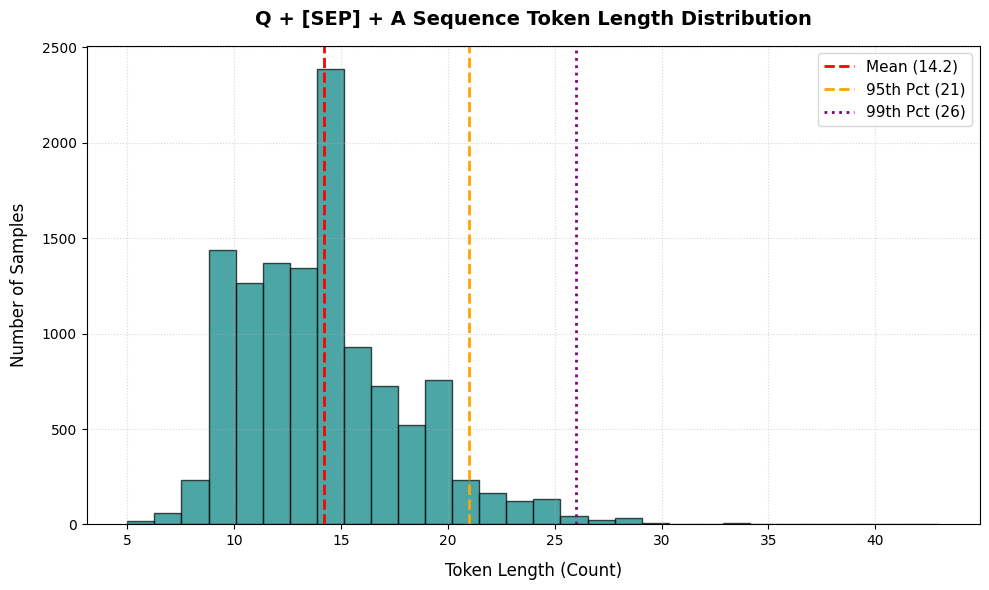

추천 문장 최대 길이: 26


In [9]:
MAX_LEN = analyze_sequence_length(data_path, tokenizer)
print(f"추천 문장 최대 길이: {MAX_LEN}")

In [29]:
# --- [Step 3: 데이터셋 및 데이터로더 생성] ---
# MAX_LEN = 26
dataset = GPT1PretrainDataset(data_path, tokenizer, max_len=MAX_LEN)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# --- [Step 4: GPT 모델 인스턴스화 및 학습] ---
# 파라미터는 편의에 맞춰 튜닝하여 사용하세요.
gpt1 = GPT1(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
).to(device)


# =========================================================================
# [1. 학습 루프 구현 (Training Loop)]
# =========================================================================
# GPT-1은 CrossEntropyLoss를 사용하여 각 위치의 다음 토큰 정답을 맞추도록 학습합니다.
# 패딩 토큰([PAD]=0)은 손실(Loss) 계산에서 제외하여 불필요한 그라디언트 전파를 막습니다.
criterion = nn.CrossEntropyLoss(ignore_index=0) 
optimizer = optim.AdamW(gpt1.parameters(), lr=1e-4, weight_decay=0.01)

print("📌 GPT-1 Pre-training 시작...")
print(f"📋 총 에폭: {EPOCHS} | 배치 크기: {dataloader.batch_size}")
print("-" * 50)
for epoch in range(EPOCHS):
    start_time = time.time()
    gpt1.train()  # 💡 Dropout 활성화를 위한 학습 모드 전환
    total_loss = 0
    
    for batch_idx, batch_inputs in enumerate(dataloader):
        # 1) 데이터를 GPU/CPU로 이동
        batch_inputs = batch_inputs.to(device) # Shape: (batch_size, MAX_LEN)
        
        # 2) Causal LM을 위한 입력과 타겟 분리 (오른쪽으로 1칸 시프트)
        # 예: 입력="오늘 너무 힘들다 [SEP]" -> 정답="너무 힘들다 [SEP] 고생"
        gpt_input = batch_inputs[:, :-1]   # (batch_size, MAX_LEN - 1)
        gpt_target = batch_inputs[:, 1:]    # (batch_size, MAX_LEN - 1)
        
        # 3) 그레디언트 초기화
        optimizer.zero_grad()
        
        # 4) Forward pass
        outputs = gpt1(gpt_input) # 출력 Shape: (batch_size, MAX_LEN-1, VOCAB_SIZE)
        
        # 5) 🚨 [해결] 텐서 메모리 비연속성 해결을 위한 .reshape() 기반 Loss 계산
        # CrossEntropyLoss는 (N, C) 형태를 받으므로 3차원 텐서를 2차원으로 펼쳐줍니다.
        flattened_outputs = outputs.reshape(-1, outputs.size(-1))
        flattened_targets = gpt_target.reshape(-1)
        
        loss = criterion(flattened_outputs, flattened_targets)
        
        # 6) Backward pass 및 가중치 업데이트 (역전파)
        loss.backward()
        
        # 💡 안정적인 학습을 위한 Gradient Clipping 추가
        torch.nn.utils.clip_grad_norm_(gpt1.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # 7) 배치 손실 기록
        total_loss += loss.item()
        
    # --- [에폭 종료 후 로그 출력] ---
    epoch_time = time.time() - start_time
    avg_loss = total_loss / len(dataloader)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] | Avg Loss: {avg_loss:.4f} | Time: {epoch_time:.2f}s")

print("-" * 50)
print("✅ GPT-1 커스텀 대화 모델 학습이 성공적으로 완료되었습니다!")

# =========================================================================
# [2. 테스트 및 문장 생성 코드 (Inference / Autoregressive Generation)]
# =========================================================================
def generate_text(model, tokenizer, prompt, max_gen_len=30, sep_token="[SEP]"):
    """
    학습된 GPT-1 모델을 사용하여 prompt 뒤에 이어질 대답을 생성(Inference)합니다.
    """
    model.eval() # 평가 모드 전환 (Dropout 비활성화)
    
    # 1) 사용자 질문 뒤에 [SEP] 특수 토큰을 붙여 인코딩 시 작점 형성
    prompt_text = f"{prompt} {sep_token}"
    
    # 커스텀 토크나이저의 encode 메서드로 ID 배열 변환 및 Tensor화
    input_ids = tokenizer.encode(prompt_text, add_bos=True) # [BOS]를 붙여 시작 경계 명시
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device) # (1, seq_len)
    
    print(f"\n💬 입력 프롬프트: {prompt_text}")
    
    # 2) 오토레그레시브(자연어 루프) 방식으로 한 토큰씩 생성
    with torch.no_grad():
        for _ in range(max_gen_len):
            # 현재까지 생성된 텍스트 입력하여 모델 추론
            logits = model(input_tensor) # Shape: (1, current_seq_len, VOCAB_SIZE)
            
            # 마지막 타임스텝(-1)의 로짓에서 가장 확률이 높은 토큰 ID 선택 (Greedy Decoding)
            next_token_id = torch.argmax(logits[:, -1, :], dim=-1).item()
            
            # 종료 토큰([EOS]=3)이 나오면 생성을 멈춤
            if next_token_id == 3: 
                break
                
            # 기존 입력 뒤에 새로 생성된 토큰 ID를 이어 붙여 다음 턴의 입력값으로 갱신
            next_token_tensor = torch.tensor([[next_token_id]], dtype=torch.long).to(device)
            input_tensor = torch.cat([input_tensor, next_token_tensor], dim=1)
            
    # 3) 최종 완성된 토큰 ID 배열을 디코딩하여 텍스트로 변환
    generated_ids = input_tensor.squeeze(0).tolist()
    decoded_output = tokenizer.decode(generated_ids)
    
    print(f"🤖 모델 답변(전체 시퀀스): {decoded_output}")
    
    # [SEP] 이후의 텍스트(답변 파트)만 파싱해서 깔끔하게 리턴
    if sep_token in decoded_output:
        answer = decoded_output.split(sep_token)[-1].strip()
        print(f"✨ 최종 추출된 답변: {answer}")
    return decoded_output

print("\n========= 🤖 챗봇 서비스 추론 테스트 =========")
test_questions = [
    "오늘 너무 힘들다",
    "10년 연애 끝 부질없네",
    "인사해줘",
    "맛있는 거 추천해줘"
]

for question in test_questions:
    response = generate_text(
        model=gpt1, 
        tokenizer=tokenizer, 
        prompt=question,
        sep_token=SEP_TOKEN
    )
    print(f"질문(Q): {question}")
    print(f"답변(A): {response}")
    print("-" * 40)

📋 총 11823개의 대화 쌍을 GPT-1 포맷으로 전처리합니다.
📌 GPT-1 Pre-training 시작...
📋 총 에폭: 20 | 배치 크기: 64
--------------------------------------------------
Epoch [01/20] | Avg Loss: 6.3355 | Time: 16.65s
Epoch [02/20] | Avg Loss: 5.6662 | Time: 16.66s
Epoch [03/20] | Avg Loss: 5.4109 | Time: 16.59s
Epoch [04/20] | Avg Loss: 5.2107 | Time: 16.32s
Epoch [05/20] | Avg Loss: 5.0330 | Time: 16.30s
Epoch [06/20] | Avg Loss: 4.8737 | Time: 16.30s
Epoch [07/20] | Avg Loss: 4.7251 | Time: 16.37s
Epoch [08/20] | Avg Loss: 4.5804 | Time: 16.29s
Epoch [09/20] | Avg Loss: 4.4380 | Time: 16.19s
Epoch [10/20] | Avg Loss: 4.2995 | Time: 16.43s
Epoch [11/20] | Avg Loss: 4.1625 | Time: 16.52s
Epoch [12/20] | Avg Loss: 4.0294 | Time: 16.53s
Epoch [13/20] | Avg Loss: 3.9020 | Time: 16.49s
Epoch [14/20] | Avg Loss: 3.7793 | Time: 16.43s
Epoch [15/20] | Avg Loss: 3.6518 | Time: 16.50s
Epoch [16/20] | Avg Loss: 3.5323 | Time: 16.43s
Epoch [17/20] | Avg Loss: 3.4128 | Time: 16.43s
Epoch [18/20] | Avg Loss: 3.2963 | Time: 16.45

In [ ]:
from torchinfo import summary

# 하이퍼파라미터 기반 가상 배치 크기 정의 (Causal LM 입력 크기)
batch_size = 64
sample_input_size = (batch_size, MAX_LEN - 1) 

print("=================== 📐 GPT-1 Model Summary ===================")
summary(
    gpt1, 
    input_size=sample_input_size, 
    dtypes=[torch.long], 
    device=device,
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
    depth=3 # 블록 내부의 디테일한 레이어까지 시각화
)

=================== 📐 GPT-1 Model Summary ===================


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Mult-Adds
GPT1                                          [64, 25]                  [64, 25, 8000]            --                        --
├─Decoder: 1-1                                --                        [64, 25, 256]             --                        --
│    └─Embedding: 2-1                         [64, 25]                  [64, 25, 256]             2,048,000                 131,072,000
│    └─PositionalEncoding: 2-2                [64, 25, 256]             [64, 25, 256]             --                        --
│    └─Dropout: 2-3                           [64, 25, 256]             [64, 25, 256]             --                        --
│    └─ModuleList: 2-4                        --                        --                        --                        --
│    │    └─DecoderLayer: 3-1                 [64, 25, 256]             [64, 25, 256]          